
# SVD Rank and Skill-Weighting Ablation

This notebook addresses the reviewer concern that the explanation for **why SVD outperforms ComplEx and RotatE** is currently intuitive but not empirically substantiated.

It runs a focused ablation over:

- **SVD rank** (`32, 64, 128, 256, 384, 512`)
- **Skill-assignment weighting**
  - `sim+graph`: paper setup (cosine similarity weights + 1-hop graph expansion)
  - `binary+graph`: binary retained links + 1-hop graph expansion
  - `sim-only`: cosine similarity weights without graph expansion
  - `binary-only`: binary retained links without graph expansion

All SVD variants are evaluated in the **same dense@100 -> rerank -> @50** setup used in the paper, with `alpha=0.5`.


In [1]:

import os
import re
import unicodedata
from collections import defaultdict
from pathlib import Path
from typing import Dict, List, Tuple

import faiss
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyterrier as pt
from scipy.sparse import csr_matrix
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import normalize

os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("VECLIB_MAXIMUM_THREADS", "1")
os.environ.setdefault("NUMEXPR_NUM_THREADS", "1")

if not pt.java.started():
    pt.java.init()

def l2_normalize(v: np.ndarray) -> np.ndarray:
    n = float(np.linalg.norm(v))
    return (v / (n + 1e-12)).astype(np.float32)

def l2_normalize_rows(M: np.ndarray) -> np.ndarray:
    M = M.astype(np.float32, copy=False)
    denom = np.linalg.norm(M, axis=1, keepdims=True) + 1e-12
    return (M / denom).astype(np.float32)

def ensure_run(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["qid"] = df["qid"].astype(str)
    df["docno"] = df["docno"].astype(str)
    if "score" not in df.columns:
        df["score"] = 0.0
    df["score"] = df["score"].astype(float)
    if "rank" not in df.columns:
        df = df.sort_values(["qid", "score"], ascending=[True, False])
        df["rank"] = df.groupby("qid").cumcount() + 1
    return df

_ws_re = re.compile(r"\s+")
_tags_re = re.compile(r"<[^>]+>")

def normalize_text(s: str) -> str:
    if s is None:
        return ""
    s = str(s)
    s = _tags_re.sub(" ", s)
    s = unicodedata.normalize("NFKC", s)
    s = s.lower()
    s = re.sub(r"[^0-9a-zA-ZäöüßÄÖÜẞ]+", " ", s)
    s = _ws_re.sub(" ", s).strip()
    return s

def safe_concat(parts):
    clean = []
    for p in parts:
        if p is None:
            continue
        p = str(p)
        if p.strip() in ("", "N/A", "nan"):
            continue
        clean.append(p)
    return " ".join(clean)

def build_doc_text(row: pd.Series) -> str:
    return safe_concat([row.get("question"), row.get("choices_processed")])


/Users/user/miniconda3/envs/KG-re-ranking/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Java started and loaded: pyterrier.java.colab, pyterrier.java, pyterrier.java.24, pyterrier.terrier.java [version=5.11 (build: craig.macdonald 2025-01-13 21:29), helper_version=0.0.8]


In [2]:

PROJECT_ROOT = Path("/Users/user/Submissions/BEA-2026").resolve()
QB_PATH = PROJECT_ROOT / "qbank.csv"
QUERIES_PATH = PROJECT_ROOT / "queries.csv"
QRELS_PATH = PROJECT_ROOT / "qrels.tsv"
ESCO_DIR = PROJECT_ROOT / "ESCO"

SKILLS_PATH = ESCO_DIR / "skills_de.csv"
REL_PATH = ESCO_DIR / "skillSkillRelations_de.csv"
HIER_PATH = ESCO_DIR / "skillsHierarchy_de.csv"

ART_DIR = PROJECT_ROOT / "artifacts" / "svd_ablation"
ART_DIR.mkdir(parents=True, exist_ok=True)

DENSE_MODEL = "deutsche-telekom/gbert-large-paraphrase-cosine"
ESCO_MODEL = "sentence-transformers/paraphrase-multilingual-mpnet-base-v2"

ESCO_TOPK_DOC = 15
ESCO_TOPK_QUERY = 20
ESCO_MIN_SIM = 0.45

K_CAND = 100
K_FINAL = 50
ALPHA = 0.5
RANDOM_STATE = 42

SVD_DIMS = [32, 64, 128, 256, 384, 512]
ABLATIONS = [
    {"scheme": "sim+graph", "weighting": "similarity", "hops": 1, "neighbor_w": 0.30},
    {"scheme": "binary+graph", "weighting": "binary", "hops": 1, "neighbor_w": 0.30},
    {"scheme": "sim-only", "weighting": "similarity", "hops": 0, "neighbor_w": 0.30},
    {"scheme": "binary-only", "weighting": "binary", "hops": 0, "neighbor_w": 0.30},
]

KGE_REFERENCE_NDCG = {
    "ComplEx": 0.5516,
    "RotatE": 0.5497,
}

print("PROJECT_ROOT:", PROJECT_ROOT)
print("ART_DIR:", ART_DIR)


PROJECT_ROOT: /Users/user/Submissions/BEA-2026
ART_DIR: /Users/user/Submissions/BEA-2026/artifacts/svd_ablation


In [3]:

qb = pd.read_csv(QB_PATH).fillna("N/A")
queries = pd.read_csv(QUERIES_PATH).fillna("")
qrels = pd.read_csv(QRELS_PATH, sep="\t").fillna(0)

qb["docno"] = qb["test_item_id"].astype(str)
qb["raw_text"] = qb.apply(build_doc_text, axis=1)
qb["text"] = qb["raw_text"].map(normalize_text)
corpus = qb[["docno", "text"]].copy()

topics = queries.rename(columns={"queries": "query"})[["qid", "query"]].copy()
topics["qid"] = topics["qid"].astype(str)
topics["query"] = topics["query"].astype(str).map(normalize_text)

qrels = qrels.rename(columns={"rel": "label"})[["qid", "docno", "label"]].copy()
qrels["qid"] = qrels["qid"].astype(str)
qrels["docno"] = qrels["docno"].astype(str)
qrels["label"] = qrels["label"].astype(int)

print("corpus:", corpus.shape)
print("topics:", topics.shape)
print("qrels:", qrels.shape)

skills_df = pd.read_csv(SKILLS_PATH).fillna("")
skills_df["conceptUri"] = skills_df["conceptUri"].astype(str).str.strip()
skills_df["preferredLabel"] = skills_df["preferredLabel"].astype(str).str.strip()

rel_df = pd.read_csv(REL_PATH).fillna("")
hier_df = pd.read_csv(HIER_PATH).fillna("")

adj: Dict[str, set] = defaultdict(set)

if "relationType" in rel_df.columns:
    rel_opt = rel_df[rel_df["relationType"].astype(str) == "optional"].copy()
else:
    rel_opt = rel_df.copy()

if "originalSkillUri" in rel_opt.columns and "relatedSkillUri" in rel_opt.columns:
    for a, b in zip(rel_opt["originalSkillUri"].astype(str), rel_opt["relatedSkillUri"].astype(str)):
        a = a.strip()
        b = b.strip()
        if a and b and a != "nan" and b != "nan":
            adj[a].add(b)
            adj[b].add(a)

lvl_cols = [c for c in ["Level 0 URI", "Level 1 URI", "Level 2 URI", "Level 3 URI"] if c in hier_df.columns]
for _, row in hier_df[lvl_cols].iterrows():
    uris = [str(row[c]).strip() for c in lvl_cols if str(row[c]).strip() and str(row[c]).strip() != "nan"]
    for u, v in zip(uris[:-1], uris[1:]):
        adj[u].add(v)
        adj[v].add(u)

print("ESCO skills:", len(skills_df))
print("Adjacency nodes:", len(adj))


corpus: (2812, 2)
topics: (15, 2)
qrels: (2755, 3)
ESCO skills: 13960
Adjacency nodes: 6173


In [4]:

class FaissDenseRetriever(pt.Transformer):
    def __init__(self, corpus_df: pd.DataFrame, model_name: str, topk: int):
        super().__init__()
        self.topk = int(topk)
        cdf = corpus_df[["docno", "text"]].copy()
        cdf["docno"] = cdf["docno"].astype(str)
        cdf["text"] = cdf["text"].astype(str)
        self.docnos = cdf["docno"].tolist()
        self.st = SentenceTransformer(model_name, device="cpu")
        xdoc = self.st.encode(
            cdf["text"].tolist(),
            convert_to_numpy=True,
            normalize_embeddings=True,
            show_progress_bar=True,
        ).astype("float32")
        self.index = faiss.IndexFlatIP(xdoc.shape[1])
        self.index.add(xdoc)

    def transform(self, topics_df: pd.DataFrame) -> pd.DataFrame:
        qids = topics_df["qid"].astype(str).tolist()
        qs = topics_df["query"].astype(str).tolist()
        q = self.st.encode(
            qs,
            convert_to_numpy=True,
            normalize_embeddings=True,
            show_progress_bar=False,
        ).astype("float32")
        scores, idxs = self.index.search(q, self.topk)
        rows = []
        for i, qid in enumerate(qids):
            for rank, (j, sc) in enumerate(zip(idxs[i], scores[i]), start=1):
                if j < 0:
                    continue
                rows.append({
                    "qid": qid,
                    "docno": self.docnos[j],
                    "score": float(sc),
                    "rank": int(rank),
                })
        return pd.DataFrame(rows)

class StaticRunSource(pt.Transformer):
    def __init__(self, run_df: pd.DataFrame):
        super().__init__()
        self.run_df = ensure_run(run_df)

    def transform(self, topics_df: pd.DataFrame) -> pd.DataFrame:
        return self.run_df.copy()

class KGReranker(pt.Transformer):
    def __init__(self, qid2vec: Dict[str, np.ndarray], docno2vec: Dict[str, np.ndarray], alpha: float = 0.5):
        super().__init__()
        self.qid2vec = qid2vec
        self.docno2vec = docno2vec
        self.alpha = float(alpha)
        self.dim = int(next(iter(docno2vec.values())).shape[0])
        self.zero = np.zeros(self.dim, dtype=np.float32)

    def transform(self, df: pd.DataFrame) -> pd.DataFrame:
        df = ensure_run(df)
        out = df.copy()
        out["orig_score"] = out["score"].astype(float)
        Q = np.vstack([self.qid2vec.get(q, self.zero) for q in out["qid"]]).astype(np.float32)
        D = np.vstack([self.docno2vec.get(d, self.zero) for d in out["docno"]]).astype(np.float32)
        kg = (l2_normalize_rows(Q) * l2_normalize_rows(D)).sum(axis=1).astype(np.float32)
        out["kg_score"] = kg.astype(float)
        out["score"] = ((1.0 - self.alpha) * out["kg_score"] + self.alpha * out["orig_score"]).astype(float)
        out = out.sort_values(["qid", "score"], ascending=[True, False])
        out["rank"] = out.groupby("qid").cumcount() + 1
        return out

def cut_k(k: int) -> pt.Transformer:
    return pt.apply.generic(lambda df: df.groupby("qid", sort=False).head(int(k)))

def eval_at_k(pipelines, topics_df, qrels_df, k_eval: int) -> pd.DataFrame:
    metrics = [
        f"ndcg_cut.{k_eval}",
        "recip_rank",
        f"P.{k_eval}",
        f"recall.{k_eval}",
        f"map_cut.{k_eval}",
    ]
    df = pt.Experiment(
        [p for _, p in pipelines],
        topics_df,
        qrels_df,
        eval_metrics=metrics,
        names=[n for n, _ in pipelines],
        verbose=True,
        validate="ignore",
    )
    df = df.rename(columns={
        f"ndcg_cut.{k_eval}": f"nDCG@{k_eval}",
        "recip_rank": f"MRR@{k_eval}",
        f"P.{k_eval}": f"Prec@{k_eval}",
        f"recall.{k_eval}": f"Recall@{k_eval}",
        f"map_cut.{k_eval}": f"MAP@{k_eval}",
    }).copy()
    p = df[f"Prec@{k_eval}"].astype(float)
    r = df[f"Recall@{k_eval}"].astype(float)
    df[f"F1@{k_eval}"] = np.where((p + r) > 0, 2 * p * r / (p + r), 0.0)
    return df

dense_cache = ART_DIR / "dense100_run.csv"
if dense_cache.exists():
    dense_run = pd.read_csv(dense_cache)
    print("Loaded cached dense run:", dense_cache)
else:
    dense100 = FaissDenseRetriever(corpus, model_name=DENSE_MODEL, topk=K_CAND)
    dense_run = dense100.transform(topics)
    dense_run.to_csv(dense_cache, index=False)
    print("Saved dense run:", dense_cache)

dense_run = ensure_run(dense_run)
dense_source = StaticRunSource(dense_run)
cut50 = cut_k(K_FINAL)

ann_metrics = eval_at_k([("ANN@100->@50", dense_source >> cut50)], topics, qrels, K_FINAL)
ann_ndcg = float(ann_metrics["nDCG@50"].iloc[0])
print("ANN nDCG@50:", ann_ndcg)


Batches:   0%|          | 0/88 [00:00<?, ?it/s]

Batches:   1%|          | 1/88 [00:05<07:35,  5.24s/it]

Batches:   2%|▏         | 2/88 [00:09<07:02,  4.91s/it]

Batches:   3%|▎         | 3/88 [00:13<06:17,  4.44s/it]

Batches:   5%|▍         | 4/88 [00:17<06:00,  4.29s/it]

...

Batches: 100%|██████████| 88/88 [03:30<00:00,  2.40s/it]

Saved dense run: /Users/user/Submissions/BEA-2026/artifacts/svd_ablation/dense100_run.csv


pt.Experiment:   0%|          | 0/1 [00:00<?, ?system/s]

pt.Experiment: 100%|██████████| 1/1 [00:00<00:00, 61.79system/s]

ANN nDCG@50: 0.5005960891853134


In [5]:

def top_skills(texts: List[str], topk: int, st_model: SentenceTransformer, vocab: List[str], index) -> List[List[Tuple[str, float]]]:
    q = st_model.encode(
        [str(t) for t in texts],
        convert_to_numpy=True,
        normalize_embeddings=True,
        show_progress_bar=False,
    ).astype("float32")
    scores, idxs = index.search(q, int(topk))
    out = []
    for i in range(len(texts)):
        pairs = []
        for j, sc in zip(idxs[i], scores[i]):
            if j < 0:
                continue
            pairs.append((vocab[j], float(sc)))
        out.append(pairs)
    return out

def pairs_to_df(ids: List[str], pairs: List[List[Tuple[str, float]]], id_col: str) -> pd.DataFrame:
    rows = []
    for _id, ps in zip(ids, pairs):
        for uri, sc in ps:
            if float(sc) < float(ESCO_MIN_SIM):
                continue
            rows.append({id_col: str(_id), "skill_uri": str(uri), "w": float(sc)})
    df = pd.DataFrame(rows)
    if df.empty:
        df = pd.DataFrame(columns=[id_col, "skill_uri", "w"])
    return df

doc_skills_cache = ART_DIR / "doc_skills_df.csv"
qid_skills_cache = ART_DIR / "qid_skills_df.csv"

if doc_skills_cache.exists() and qid_skills_cache.exists():
    doc_skills_df = pd.read_csv(doc_skills_cache)
    qid_skills_df = pd.read_csv(qid_skills_cache)
    print("Loaded cached skill links")
else:
    skills_nn = skills_df[["conceptUri", "preferredLabel"]].drop_duplicates("conceptUri").copy()
    skills_nn = skills_nn[(skills_nn["conceptUri"] != "") & (skills_nn["conceptUri"] != "nan")]
    skills_nn = skills_nn[(skills_nn["preferredLabel"] != "") & (skills_nn["preferredLabel"] != "nan")].reset_index(drop=True)
    skill_vocab = skills_nn["conceptUri"].tolist()
    skill_labels = skills_nn["preferredLabel"].tolist()

    st_esco = SentenceTransformer(ESCO_MODEL, device="cpu")
    X = st_esco.encode(
        skill_labels,
        convert_to_numpy=True,
        normalize_embeddings=True,
        show_progress_bar=True,
    ).astype("float32")
    index_esco = faiss.IndexFlatIP(X.shape[1])
    index_esco.add(X)

    doc_pairs = top_skills(corpus["text"].astype(str).tolist(), ESCO_TOPK_DOC, st_esco, skill_vocab, index_esco)
    qid_pairs = top_skills(topics["query"].astype(str).tolist(), ESCO_TOPK_QUERY, st_esco, skill_vocab, index_esco)

    doc_skills_df = pairs_to_df(corpus["docno"].astype(str).tolist(), doc_pairs, "docno")
    qid_skills_df = pairs_to_df(topics["qid"].astype(str).tolist(), qid_pairs, "qid")

    doc_skills_df.to_csv(doc_skills_cache, index=False)
    qid_skills_df.to_csv(qid_skills_cache, index=False)
    print("Saved skill-link caches")

print("doc_skills_df:", doc_skills_df.shape, "unique docs:", doc_skills_df["docno"].nunique())
print("qid_skills_df:", qid_skills_df.shape, "unique qids:", qid_skills_df["qid"].nunique())

def apply_weighting(df: pd.DataFrame, weighting: str) -> pd.DataFrame:
    out = df.copy()
    if weighting == "binary":
        out["w"] = 1.0
    elif weighting == "similarity":
        out["w"] = out["w"].astype(float)
    else:
        raise ValueError(weighting)
    return out

def expand_pairs(skills_df_w: pd.DataFrame, id_col: str, hops: int, neighbor_w: float) -> pd.DataFrame:
    if skills_df_w.empty:
        return skills_df_w.copy()
    base = skills_df_w.copy()
    base[id_col] = base[id_col].astype(str)
    base["skill_uri"] = base["skill_uri"].astype(str)
    base["w"] = base["w"].astype(float)
    base = base.groupby([id_col, "skill_uri"], as_index=False)["w"].max()
    current = base.copy()
    all_rows = [base]
    for hop in range(1, int(hops) + 1):
        dec = float(neighbor_w) ** hop
        rows = []
        for _id, g in current.groupby(id_col, sort=False):
            for s, w in zip(g["skill_uri"].tolist(), g["w"].tolist()):
                neigh = adj.get(str(s), set())
                if not neigh:
                    continue
                for n in neigh:
                    rows.append({id_col: str(_id), "skill_uri": str(n), "w": float(w) * dec})
        if not rows:
            break
        nxt = pd.DataFrame(rows)
        nxt = nxt.groupby([id_col, "skill_uri"], as_index=False)["w"].max()
        all_rows.append(nxt)
        current = nxt
    out = pd.concat(all_rows, ignore_index=True)
    out = out.groupby([id_col, "skill_uri"], as_index=False)["w"].max()
    return out

def build_svd_vectors(doc_df: pd.DataFrame, qid_df: pd.DataFrame, svd_dim: int):
    svd_skill_vocab = pd.Index(pd.concat([
        doc_df["skill_uri"].astype(str),
        qid_df["skill_uri"].astype(str),
    ])).unique().tolist()
    skill2idx = {u: i for i, u in enumerate(svd_skill_vocab)}
    n_sk = len(svd_skill_vocab)

    doc_ids = corpus["docno"].astype(str).unique().tolist()
    qid_ids = topics["qid"].astype(str).unique().tolist()
    doc2row = {d: i for i, d in enumerate(doc_ids)}
    qid2row = {q: i for i, q in enumerate(qid_ids)}

    def to_sparse(df, id_col, id2row):
        if df.empty:
            return csr_matrix((len(id2row), n_sk), dtype=np.float32)
        r = df[id_col].astype(str).map(id2row).to_numpy()
        c = df["skill_uri"].astype(str).map(skill2idx).to_numpy()
        v = df["w"].astype(float).to_numpy()
        return csr_matrix((v, (r, c)), shape=(len(id2row), n_sk), dtype=np.float32)

    X_doc = to_sparse(doc_df, "docno", doc2row)
    X_qid = to_sparse(qid_df, "qid", qid2row)

    max_dim = min(X_doc.shape[0] - 1, X_doc.shape[1] - 1)
    if svd_dim >= max_dim:
        dim = max_dim
    else:
        dim = svd_dim

    svd = TruncatedSVD(n_components=dim, random_state=RANDOM_STATE)
    E_doc = normalize(svd.fit_transform(X_doc))
    E_qid = normalize(svd.transform(X_qid))
    explained = float(svd.explained_variance_ratio_.sum())

    docno2kg = {doc_ids[i]: E_doc[i].astype(np.float32) for i in range(len(doc_ids))}
    qid2kg = {qid_ids[i]: E_qid[i].astype(np.float32) for i in range(len(qid_ids))}
    return docno2kg, qid2kg, explained, dim

rows = []
for cfg in ABLATIONS:
    print("\n=== Running scheme:", cfg["scheme"], "===")
    doc_base = apply_weighting(doc_skills_df, cfg["weighting"])
    qid_base = apply_weighting(qid_skills_df, cfg["weighting"])
    doc_aug = expand_pairs(doc_base, "docno", cfg["hops"], cfg["neighbor_w"])
    qid_aug = expand_pairs(qid_base, "qid", cfg["hops"], cfg["neighbor_w"])

    for svd_dim in SVD_DIMS:
        docno2kg, qid2kg, explained, used_dim = build_svd_vectors(doc_aug, qid_aug, svd_dim)
        kg = KGReranker(qid2kg, docno2kg, alpha=ALPHA)
        name = f"{cfg['scheme']} | SVD@{used_dim}"
        metrics = eval_at_k([(name, dense_source >> kg >> cut50)], topics, qrels, K_FINAL).iloc[0]
        rows.append({
            "scheme": cfg["scheme"],
            "weighting": cfg["weighting"],
            "hops": cfg["hops"],
            "neighbor_w": cfg["neighbor_w"],
            "svd_dim": used_dim,
            "explained_variance": explained,
            "nDCG@50": float(metrics["nDCG@50"]),
            "MRR@50": float(metrics["MRR@50"]),
            "Prec@50": float(metrics["Prec@50"]),
            "Recall@50": float(metrics["Recall@50"]),
            "F1@50": float(metrics["F1@50"]),
            "MAP@50": float(metrics["MAP@50"]),
        })
        print(name, "nDCG@50=", rows[-1]["nDCG@50"], "explained_var=", explained)

results_df = pd.DataFrame(rows).sort_values(["nDCG@50", "scheme", "svd_dim"], ascending=[False, True, True]).reset_index(drop=True)
results_df["Delta_vs_ANN"] = results_df["nDCG@50"] - ann_ndcg
results_df["Beats_ComplEx_ref"] = results_df["nDCG@50"] > KGE_REFERENCE_NDCG["ComplEx"]
results_df["Beats_RotatE_ref"] = results_df["nDCG@50"] > KGE_REFERENCE_NDCG["RotatE"]

metrics_path = ART_DIR / "svd_rank_weighting_ablation_metrics.csv"
results_df.to_csv(metrics_path, index=False)
print("\nSaved metrics to:", metrics_path)
results_df.head(12)


Batches:   0%|          | 0/436 [00:00<?, ?it/s]

Batches:   0%|          | 1/436 [00:00<06:04,  1.19it/s]

Batches:   0%|          | 2/436 [00:01<03:54,  1.85it/s]

Batches:   1%|          | 3/436 [00:01<03:05,  2.34it/s]

Batches:   1%|          | 4/436 [00:01<02:43,  2.64it/s]

...

binary-only | SVD@384 nDCG@50= 0.5973924812522637 explained_var= 0.689841628074646


pt.Experiment:   0%|          | 0/1 [00:00<?, ?system/s]

pt.Experiment: 100%|██████████| 1/1 [00:00<00:00, 78.06system/s]

binary-only | SVD@512 nDCG@50= 0.6367661398609268 explained_var= 0.751620352268219

Saved metrics to: /Users/user/Submissions/BEA-2026/artifacts/svd_ablation/svd_rank_weighting_ablation_metrics.csv


,scheme,weighting,hops,neighbor_w,svd_dim,explained_variance,nDCG@50,MRR@50,Prec@50,Recall@50,F1@50,MAP@50,Delta_vs_ANN,Beats_ComplEx_ref,Beats_RotatE_ref
0,sim-only,similarity,0,0.3,512,0.772856,0.640077,0.904762,0.553333,0.476588,0.512101,0.406237,0.139481,True,True
1,sim+graph,similarity,1,0.3,384,0.728958,0.639711,0.936667,0.556000,0.471055,0.510015,0.409833,0.139115,True,True
2,binary-only,binary,0,0.3,512,0.751620,0.636766,0.904167,0.554667,0.476411,0.512569,0.403988,0.136170,True,True
3,sim+graph,similarity,1,0.3,512,0.786571,0.636379,0.937037,0.550667,0.466652,0.505190,0.405569,0.135783,True,True
4,binary+graph,binary,1,0.3,384,0.705754,0.614718,0.903175,0.556000,0.470920,0.509936,0.374118,0.114122,True,True
5,sim-only,similarity,0,0.3,384,0.713569,0.614568,0.871429,0.554667,0.477257,0.513059,0.373734,0.113971,True,True
6,binary+graph,binary,1,0.3,512,0.765955,0.613593,0.903030,0.556000,0.470105,0.509457,0.371891,0.112997,True,True
7,sim+graph,similarity,1,0.3,128,0.524352,0.601237,0.857854,0.553333,0.466551,0.506250,0.363223,0.100641,True,True
8,binary+graph,binary,1,0.3,256,0.624197,0.600894,0.885897,0.558667,0.470759,0.510959,0.359383,0.100298,True,True
9,sim+graph,similarity,1,0.3,256,0.650035,0.598634,0.886667,0.554667,0.467536,0.507388,0.358092,0.098038,True,True


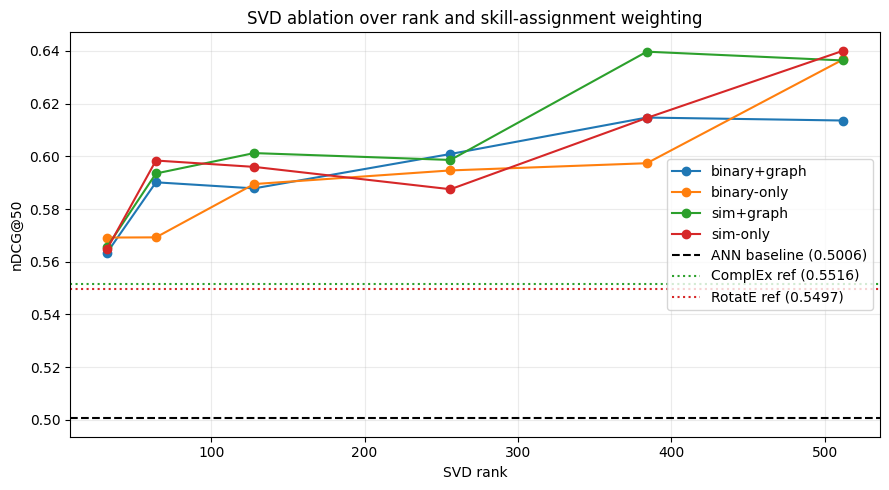

Saved best-per-scheme table to: /Users/user/Submissions/BEA-2026/artifacts/svd_ablation/svd_rank_weighting_best_by_scheme.csv
Saved summary to: /Users/user/Submissions/BEA-2026/artifacts/svd_ablation/svd_rank_weighting_summary.txt
Saved plot to: /Users/user/Submissions/BEA-2026/artifacts/svd_ablation/svd_rank_weighting_ablation_ndcg.png


,scheme,weighting,hops,neighbor_w,svd_dim,explained_variance,nDCG@50,MRR@50,Prec@50,Recall@50,F1@50,MAP@50,Delta_vs_ANN,Beats_ComplEx_ref,Beats_RotatE_ref
3,sim-only,similarity,0,0.3,512,0.772856,0.640077,0.904762,0.553333,0.476588,0.512101,0.406237,0.139481,True,True
2,sim+graph,similarity,1,0.3,384,0.728958,0.639711,0.936667,0.556000,0.471055,0.510015,0.409833,0.139115,True,True
1,binary-only,binary,0,0.3,512,0.751620,0.636766,0.904167,0.554667,0.476411,0.512569,0.403988,0.136170,True,True
0,binary+graph,binary,1,0.3,384,0.705754,0.614718,0.903175,0.556000,0.470920,0.509936,0.374118,0.114122,True,True


In [6]:

best_per_scheme = (
    results_df.sort_values(["scheme", "nDCG@50"], ascending=[True, False])
    .groupby("scheme", as_index=False)
    .first()
    .sort_values("nDCG@50", ascending=False)
)
best_path = ART_DIR / "svd_rank_weighting_best_by_scheme.csv"
best_per_scheme.to_csv(best_path, index=False)

overall_best = results_df.iloc[0].to_dict()
summary_lines = [
    f"ANN@100->@50 nDCG@50: {ann_ndcg:.4f}",
    f"ComplEx reference nDCG@50: {KGE_REFERENCE_NDCG['ComplEx']:.4f}",
    f"RotatE reference nDCG@50: {KGE_REFERENCE_NDCG['RotatE']:.4f}",
    "",
    f"Best SVD ablation: {overall_best['scheme']} @ {int(overall_best['svd_dim'])} dims",
    f"Best SVD nDCG@50: {overall_best['nDCG@50']:.4f}",
    f"Explained variance: {overall_best['explained_variance']:.4f}",
]
summary_path = ART_DIR / "svd_rank_weighting_summary.txt"
summary_path.write_text("\n".join(summary_lines))

plt.figure(figsize=(9, 5))
for scheme, g in results_df.groupby("scheme"):
    gg = g.sort_values("svd_dim")
    plt.plot(gg["svd_dim"], gg["nDCG@50"], marker="o", label=scheme)
plt.axhline(ann_ndcg, linestyle="--", color="black", label=f"ANN baseline ({ann_ndcg:.4f})")
plt.axhline(KGE_REFERENCE_NDCG["ComplEx"], linestyle=":", color="tab:green", label=f"ComplEx ref ({KGE_REFERENCE_NDCG['ComplEx']:.4f})")
plt.axhline(KGE_REFERENCE_NDCG["RotatE"], linestyle=":", color="tab:red", label=f"RotatE ref ({KGE_REFERENCE_NDCG['RotatE']:.4f})")
plt.xlabel("SVD rank")
plt.ylabel("nDCG@50")
plt.title("SVD ablation over rank and skill-assignment weighting")
plt.grid(alpha=0.25)
plt.legend()
plot_path = ART_DIR / "svd_rank_weighting_ablation_ndcg.png"
plt.tight_layout()
plt.savefig(plot_path, dpi=180)
plt.show()

print("Saved best-per-scheme table to:", best_path)
print("Saved summary to:", summary_path)
print("Saved plot to:", plot_path)

best_per_scheme



## How to use this in the paper

The outputs in `artifacts/svd_ablation/` are designed to support a short reviewer-facing discussion such as:

- whether SVD remains strong across a range of latent ranks
- whether similarity-weighted assignments help more than binary assignments
- whether graph-augmented assignments help more than non-augmented assignments
- whether the best SVD settings consistently stay above the ComplEx/RotatE reference results
